# Driver's License Test - ML Analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Drivers License Data.csv")

In [3]:
df.head()

,Applicant ID,Gender,Age Group,Race,Training,Signals,Yield,Speed Control,Night Drive,Road Signs,Steer Control,Mirror Usage,Confidence,Parking,Theory Test,Reactions,Qualified
0,AID0001,Male,Young Adult,Other,NaN,38.48,30.29,37.03,33.53,39.61,58.16,53.42,35.32,38.19,70.68,Average,No
1,AID0002,Female,Young Adult,Black,NaN,51.76,19.13,63.05,34.87,19.56,16.48,27.97,22.91,24.23,78.18,Average,No
2,AID0003,Male,Middle Age,Black,NaN,30.21,48.13,43.13,42.43,60.93,20.74,28.86,32.32,44.11,79.60,Fast,Yes
3,AID0004,Male,Young Adult,Other,NaN,34.75,47.28,50.49,42.10,22.52,33.87,48.52,24.90,37.56,57.34,Average,No
4,AID0005,Male,Teenager,Other,Advanced,78.52,83.93,59.79,52.68,67.47,89.24,30.31,43.85,55.91,78.44,Average,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Applicant ID   500 non-null    object 
 1   Gender         500 non-null    object 
 2   Age Group      500 non-null    object 
 3   Race           500 non-null    object 
 4   Training       350 non-null    object 
 5   Signals        500 non-null    float64
 6   Yield          500 non-null    float64
 7   Speed Control  500 non-null    float64
 8   Night Drive    500 non-null    float64
 9   Road Signs     500 non-null    float64
 10  Steer Control  500 non-null    float64
 11  Mirror Usage   500 non-null    float64
 12  Confidence     500 non-null    float64
 13  Parking        500 non-null    float64
 14  Theory Test    500 non-null    float64
 15  Reactions      500 non-null    object 
 16  Qualified      500 non-null    object 
dtypes: float64(10), object(7)
memory usage: 66.5+ KB


In [5]:
df.describe()

,Signals,Yield,Speed Control,Night Drive,Road Signs,Steer Control,Mirror Usage,Confidence,Parking,Theory Test
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,48.525460,47.784000,47.931740,47.877760,47.793440,47.429480,48.157580,47.654440,48.452360,70.623380
std,16.294927,16.062178,15.601242,15.302693,16.042885,15.580004,15.459866,16.056021,15.705702,17.864177
min,0.770000,0.000000,0.000000,1.740000,0.000000,0.000000,0.000000,5.120000,0.000000,40.100000
25%,38.097500,36.915000,37.297500,37.387500,36.547500,37.340000,38.355000,37.020000,37.460000,54.920000
50%,48.415000,48.950000,49.405000,48.160000,49.310000,48.220000,48.360000,48.255000,49.400000,69.855000
75%,59.357500,58.977500,58.392500,58.792500,58.772500,57.515000,58.795000,59.027500,59.262500,86.685000
max,95.610000,94.410000,89.430000,89.930000,88.870000,89.240000,90.770000,90.280000,88.360000,99.750000


In [6]:
df.shape

(500, 17)

## EDA

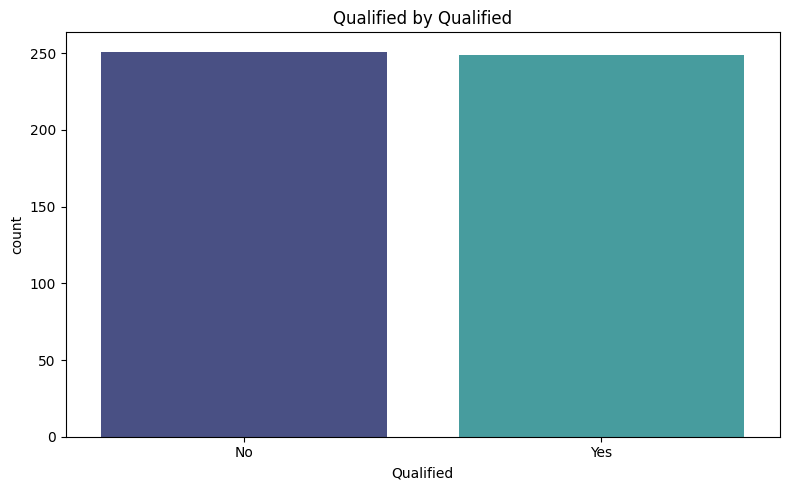

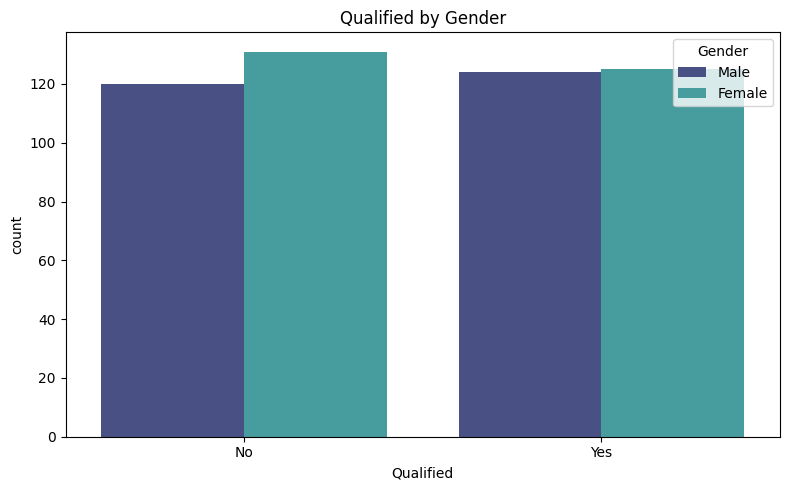

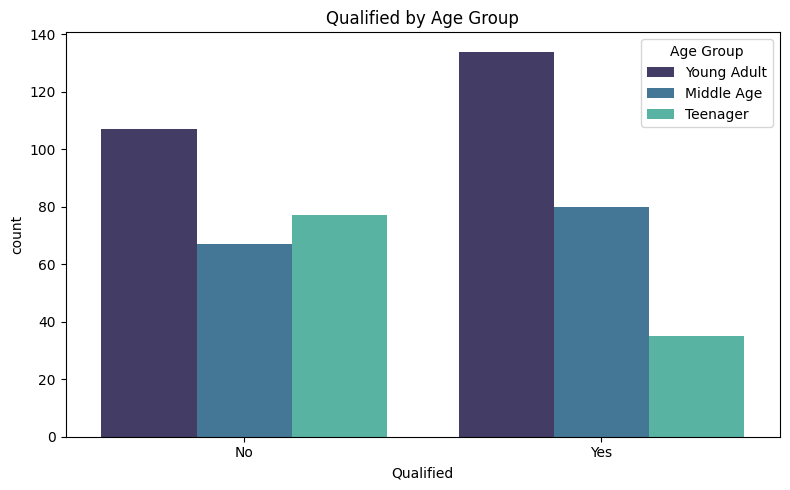

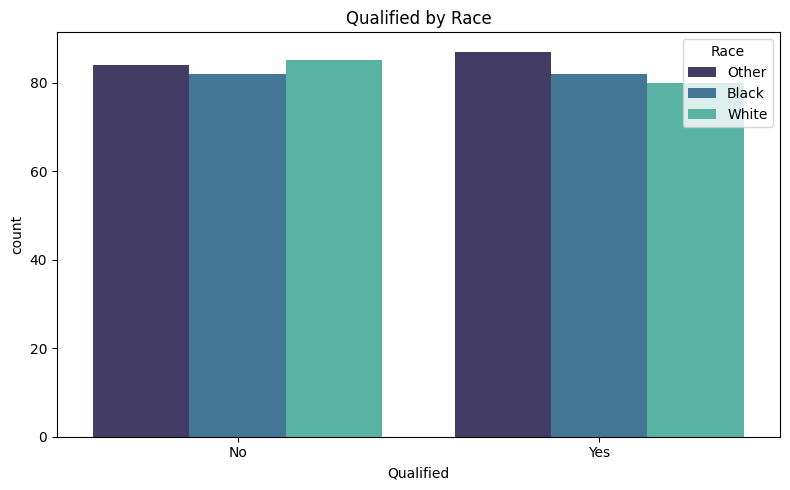

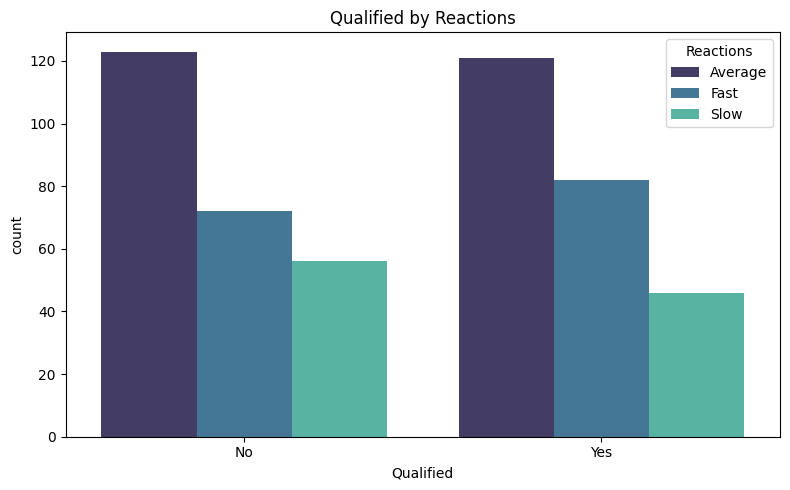

In [7]:
clist = ['Qualified', 'Gender','Age Group','Race','Reactions']

for column in clist:
    plt.figure(figsize=(8, 5))  # Create a new figure for each plot
    sns.countplot(x='Qualified', data=df, hue=column, palette='mako')
    plt.title(f'Qualified by {column}')
    plt.tight_layout()

In [8]:
df.isnull().sum()

Applicant ID       0
Gender             0
Age Group          0
Race               0
Training         150
Signals            0
Yield              0
Speed Control      0
Night Drive        0
Road Signs         0
Steer Control      0
Mirror Usage       0
Confidence         0
Parking            0
Theory Test        0
Reactions          0
Qualified          0
dtype: int64

<Axes: >

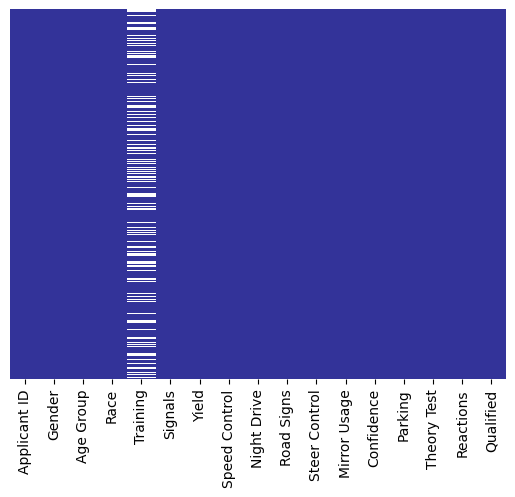

In [9]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='terrain')

<Axes: xlabel='Training', ylabel='Age Group'>

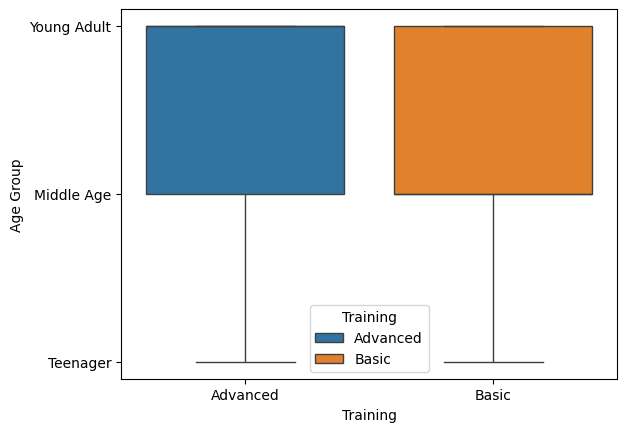

In [10]:
sns.boxplot(x='Training', y='Age Group', data=df, hue='Training')

#### Categorical Variable Association with Training column

In [11]:
from scipy.stats import chi2_contingency
import numpy as np

df_known = df[df['Training'].notna()]

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))  # Bias correction
    rcorr = r - ((r - 1)**2)/(n - 1)
    kcorr = k - ((k - 1)**2)/(n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

cat_columns = df.select_dtypes(include='object').columns.drop('Training')
for col in cat_columns:
    v = cramers_v(df_known['Training'], df_known[col])
    print(f"Cramér's V between Category and {col}: {v:.3f}")

Cramér's V between Category and Applicant ID: nan
Cramér's V between Category and Gender: 0.000
Cramér's V between Category and Age Group: 0.037
Cramér's V between Category and Race: 0.000
Cramér's V between Category and Reactions: 0.047
Cramér's V between Category and Qualified: 0.328


C:\Users\troyf\AppData\Local\Temp\ipykernel_11988\780674475.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


#### Continous Variable Association with Training column

In [12]:
from sklearn.feature_selection import f_classif

num_cols = df.select_dtypes(include=np.number).columns
X = df_known[num_cols]
y = df_known['Training']

f_values, p_values = f_classif(X, y)
for col, f, p in zip(num_cols, f_values, p_values):
    print(f'{col}: F = {f:.2f}, p = {p:.4f}')

Signals: F = 68.86, p = 0.0000
Yield: F = 48.54, p = 0.0000
Speed Control: F = 60.58, p = 0.0000
Night Drive: F = 75.83, p = 0.0000
Road Signs: F = 53.41, p = 0.0000
Steer Control: F = 52.00, p = 0.0000
Mirror Usage: F = 55.08, p = 0.0000
Confidence: F = 36.72, p = 0.0000
Parking: F = 58.75, p = 0.0000
Theory Test: F = 0.00, p = 0.9519


#### Assessing if missing values are MCAR (Missing Completely at Random)

In [13]:
df['is_missing'] = df['Training'].isna()

categorical_cols = ['Gender', 'Age Group', 'Race']
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['is_missing'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    print(f"{col}: p = {p:.4f}")

Gender: p = 0.6534
Age Group: p = 0.2328
Race: p = 0.6678


In [14]:
from scipy.stats import ttest_ind

for col in num_cols:
    group_missing = df[df['is_missing']][col].dropna()
    group_not_missing = df[~df['is_missing']][col].dropna()
    stat, p = ttest_ind(group_missing, group_not_missing, equal_var=False)
    print(f"{col}: p = {p:.4f}")

Signals: p = 0.0000
Yield: p = 0.0000
Speed Control: p = 0.0000
Night Drive: p = 0.0000
Road Signs: p = 0.0000
Steer Control: p = 0.0000
Mirror Usage: p = 0.0000
Confidence: p = 0.0000
Parking: p = 0.0000
Theory Test: p = 0.4047


In [15]:
#Dropping column with missing values since they appear to be MCAR
df.drop(['Training','Applicant ID','is_missing'], axis=1, inplace=True)

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

In [17]:
df_encoded.head()

,Signals,Yield,Speed Control,Night Drive,Road Signs,Steer Control,Mirror Usage,Confidence,Parking,Theory Test,Gender_Male,Age Group_Teenager,Age Group_Young Adult,Race_Other,Race_White,Reactions_Fast,Reactions_Slow,Qualified_Yes
0,38.48,30.29,37.03,33.53,39.61,58.16,53.42,35.32,38.19,70.68,1,0,1,1,0,0,0,0
1,51.76,19.13,63.05,34.87,19.56,16.48,27.97,22.91,24.23,78.18,0,0,1,0,0,0,0,0
2,30.21,48.13,43.13,42.43,60.93,20.74,28.86,32.32,44.11,79.60,1,0,0,0,0,1,0,1
3,34.75,47.28,50.49,42.10,22.52,33.87,48.52,24.90,37.56,57.34,1,0,1,1,0,0,0,0
4,78.52,83.93,59.79,52.68,67.47,89.24,30.31,43.85,55.91,78.44,1,1,0,1,0,0,0,1


#### Model Building

In [20]:
#Assigning predictor and target variables
X = df_encoded.drop('Qualified_Yes', axis=1)
y = df_encoded['Qualified_Yes']

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [22]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=1000)

In [23]:
logmodel.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
predictions = logmodel.predict(X_test)

#### Interpreting Results

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.78      0.82        68
           1       0.83      0.89      0.86        82

    accuracy                           0.84       150
   macro avg       0.84      0.83      0.84       150
weighted avg       0.84      0.84      0.84       150



In [27]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

array([[53, 15],
       [ 9, 73]], dtype=int64)

In [28]:
logmodel.coef_

array([[ 0.03084651,  0.02307118,  0.02045561,  0.00720265,  0.03873419,
         0.01143635,  0.0379758 ,  0.04756226,  0.04225739, -0.01023451,
         0.42232839,  1.36508312,  0.51166009,  0.23414059, -0.27692915,
         0.44132045,  0.25924249]])

In [29]:
cdf = pd.DataFrame(logmodel.coef_.T, X.columns, columns=['Coeff']).sort_values(by='Coeff', ascending=False)
cdf

,Coeff
Age Group_Teenager,1.365083
Age Group_Young Adult,0.511660
Reactions_Fast,0.441320
Gender_Male,0.422328
Reactions_Slow,0.259242
Race_Other,0.234141
Confidence,0.047562
Parking,0.042257
Road Signs,0.038734
Mirror Usage,0.037976


In [35]:
for idx, value in zip(cdf.index, cdf['Coeff']):
    if value > 0:
        print(f"| {idx} | increases the log odds of passing the drivers test by: {value:.2f}")
    else:
        print(f"| {idx} | decreases the log odds of passing the drivers test by: {value:.2f}")

| Age Group_Teenager | increases the log odds of passing the drivers test by: 1.37
| Age Group_Young Adult | increases the log odds of passing the drivers test by: 0.51
| Reactions_Fast | increases the log odds of passing the drivers test by: 0.44
| Gender_Male | increases the log odds of passing the drivers test by: 0.42
| Reactions_Slow | increases the log odds of passing the drivers test by: 0.26
| Race_Other | increases the log odds of passing the drivers test by: 0.23
| Confidence | increases the log odds of passing the drivers test by: 0.05
| Parking | increases the log odds of passing the drivers test by: 0.04
| Road Signs | increases the log odds of passing the drivers test by: 0.04
| Mirror Usage | increases the log odds of passing the drivers test by: 0.04
| Signals | increases the log odds of passing the drivers test by: 0.03
| Yield | increases the log odds of passing the drivers test by: 0.02
| Speed Control | increases the log odds of passing the drivers test by: 0.02
| S